In [109]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


## Business Problem

Olist operates a multi-seller e-commerce marketplace connecting customers and merchants across Brazil. Leadership requires a comprehensive understanding of marketplace performance, customer behavior, operational efficiency, and revenue growth drivers.

The objective of this notebook is to establish a KPI framework that measures marketplace health across four key dimensions:

1. Growth Performance
2. Customer Behavior
3. Delivery Operations
4. Customer Satisfaction

The analysis will identify strengths, weaknesses, and opportunities for improvement while creating a baseline for future experimentation and machine learning initiatives.


# 1: Load Clean Dataset

In [110]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv",
    parse_dates=[ 'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_customer_date',
        'order_estimated_delivery_date']
)

print(master.shape)

master.head()

(112650, 48)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# 2:  KPI Framework

In [111]:
master["order_month"] = master["order_purchase_timestamp"].dt.to_period('M')

In [112]:
monthly_kpis = master.groupby('order_month').agg(
        revenue=('total_payment_value', 'sum'),
        orders=('order_id', 'nunique'),
        customers=('customer_unique_id', 'nunique'),
        sellers=('seller_id', 'nunique'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        on_time_rate=('on_time_delivery', 'mean')
).reset_index()

In [113]:
monthly_kpis

,order_month,revenue,orders,customers,sellers,avg_review_score,avg_delivery_days,on_time_rate
0,2016-09,347.52,3,3,3,1.000000,54.813194,0.000000
1,2016-10,73914.58,308,305,143,3.596639,19.523707,0.870523
2,2016-12,19.62,1,1,1,5.000000,4.693021,1.000000
3,2017-01,187779.41,789,755,227,4.058263,12.641425,0.928796
4,2017-02,344134.79,1733,1708,427,4.052062,13.172742,0.920554
5,2017-03,526961.66,2641,2601,499,4.060525,12.983647,0.911333
6,2017-04,505665.53,2391,2359,506,4.004134,14.844664,0.885246
7,2017-05,724504.55,3660,3588,583,4.134277,11.453805,0.931335
8,2017-06,600753.27,3217,3154,539,4.131853,11.982161,0.937203
9,2017-07,737293.08,3969,3894,606,4.145759,11.436558,0.941801


In [114]:
# AOV = Average Order Value
monthly_kpis['aov'] = (monthly_kpis['revenue'] /monthly_kpis['orders'])

In [115]:
# Revenue per Customer
monthly_kpis['revenue_per_customer'] = ( monthly_kpis['revenue'] /monthly_kpis['customers'])

In [116]:
# Orders per Customer
monthly_kpis['orders_per_customer'] = (monthly_kpis['orders']/monthly_kpis['customers'])

In [117]:
# Revenue Growth
monthly_kpis['revenue_growth_pct'] = (monthly_kpis['revenue'].pct_change()* 100)

In [118]:
# Customer Growth
monthly_kpis['customer_growth_pct'] = (monthly_kpis['customers'].pct_change()* 100)

In [119]:
#Order Growth
monthly_kpis['order_growth_pct'] = (monthly_kpis['orders'].pct_change()* 100)

In [120]:
monthly_kpis.round(2)

,order_month,revenue,orders,customers,sellers,avg_review_score,avg_delivery_days,on_time_rate,aov,revenue_per_customer,orders_per_customer,revenue_growth_pct,customer_growth_pct,order_growth_pct
0,2016-09,347.52,3,3,3,1.00,54.81,0.00,115.84,115.84,1.00,NaN,NaN,NaN
1,2016-10,73914.58,308,305,143,3.60,19.52,0.87,239.98,242.34,1.01,21169.16,10066.67,10166.67
2,2016-12,19.62,1,1,1,5.00,4.69,1.00,19.62,19.62,1.00,-99.97,-99.67,-99.68
3,2017-01,187779.41,789,755,227,4.06,12.64,0.93,238.00,248.71,1.05,956981.60,75400.00,78800.00
4,2017-02,344134.79,1733,1708,427,4.05,13.17,0.92,198.58,201.48,1.01,83.27,126.23,119.65
5,2017-03,526961.66,2641,2601,499,4.06,12.98,0.91,199.53,202.60,1.02,53.13,52.28,52.39
6,2017-04,505665.53,2391,2359,506,4.00,14.84,0.89,211.49,214.36,1.01,-4.04,-9.30,-9.47
7,2017-05,724504.55,3660,3588,583,4.13,11.45,0.93,197.95,201.92,1.02,43.28,52.10,53.07
8,2017-06,600753.27,3217,3154,539,4.13,11.98,0.94,186.74,190.47,1.02,-17.08,-12.10,-12.10
9,2017-07,737293.08,3969,3894,606,4.15,11.44,0.94,185.76,189.34,1.02,22.73,23.46,23.38


In [121]:
kpi_summary = pd.DataFrame({

    'Metric': ['Revenue','Orders','Customers','Sellers',
        'AOV','Average Review','Average Delivery Days',
               'On-Time Rate'],

    'Value': [ master['total_payment_value'].sum(),
        master['order_id'].nunique(),
        master['customer_unique_id'].nunique(),
        master['seller_id'].nunique(),
        master['total_payment_value'].sum()/master['order_id'].nunique(),
        master['review_score'].mean(),
        master['delivery_days'].mean(),
        master['on_time_delivery'].mean() * 100
    ]
})

kpi_summary

,Metric,Value
0,Revenue,2.030813e+07
1,Orders,9.866600e+04
2,Customers,9.542000e+04
3,Sellers,3.095000e+03
4,AOV,2.058271e+02
5,Average Review,4.032854e+00
6,Average Delivery Days,1.247263e+01
7,On-Time Rate,9.008522e+01


In [122]:
monthly_kpis.head()

,order_month,revenue,orders,customers,sellers,avg_review_score,avg_delivery_days,on_time_rate,aov,revenue_per_customer,orders_per_customer,revenue_growth_pct,customer_growth_pct,order_growth_pct
0,2016-09,347.52,3,3,3,1.000000,54.813194,0.000000,115.840000,115.840000,1.000000,NaN,NaN,NaN
1,2016-10,73914.58,308,305,143,3.596639,19.523707,0.870523,239.982403,242.342885,1.009836,21169.158610,10066.666667,10166.666667
2,2016-12,19.62,1,1,1,5.000000,4.693021,1.000000,19.620000,19.620000,1.000000,-99.973456,-99.672131,-99.675325
3,2017-01,187779.41,789,755,227,4.058263,12.641425,0.928796,237.996717,248.714450,1.045033,956981.600408,75400.000000,78800.000000
4,2017-02,344134.79,1733,1708,427,4.052062,13.172742,0.920554,198.577490,201.484069,1.014637,83.265455,126.225166,119.645120


In [123]:
monthly_kpis.describe()


,revenue,orders,customers,sellers,avg_review_score,avg_delivery_days,on_time_rate,aov,revenue_per_customer,orders_per_customer,revenue_growth_pct,customer_growth_pct,order_growth_pct
count,2.400000e+01,24.000000,24.000000,24.000000,24.000000,23.000000,24.000000,24.000000,24.000000,24.000000,23.000000,23.000000,23.000000
mean,8.461723e+05,4111.083333,4054.958333,685.041667,3.818639,14.247717,0.834718,194.647336,197.501224,1.013624,42530.975474,3720.546672,3872.414092
std,5.424075e+05,2615.223208,2586.244759,403.392513,0.905542,9.394266,0.261396,45.333448,46.450641,0.009355,199391.987925,15765.567888,16470.288489
min,1.962000e+01,1.000000,1.000000,1.000000,1.000000,4.693021,0.000000,19.620000,19.620000,1.000000,-99.986463,-99.984402,-99.984501
25%,4.652828e+05,2226.500000,2196.250000,481.000000,3.925205,11.322608,0.880193,189.623337,191.469992,1.008437,-8.147565,-8.746158,-8.375715
50%,9.429777e+05,4268.000000,4190.500000,719.500000,4.064235,11.982161,0.917818,201.105632,204.613272,1.013805,4.170064,3.220093,2.853499
75%,1.317463e+06,6512.500000,6442.500000,976.500000,4.139850,14.944354,0.935116,215.576296,217.625025,1.017945,39.163176,40.112517,40.386535
max,1.583869e+06,7451.000000,7342.000000,1278.000000,5.000000,54.813194,1.000000,239.982403,248.714450,1.045033,956981.600408,75400.000000,78800.000000


In [124]:
kpi_summary

,Metric,Value
0,Revenue,2.030813e+07
1,Orders,9.866600e+04
2,Customers,9.542000e+04
3,Sellers,3.095000e+03
4,AOV,2.058271e+02
5,Average Review,4.032854e+00
6,Average Delivery Days,1.247263e+01
7,On-Time Rate,9.008522e+01


## Executive KPI Assessment

The marketplace generated approximately 20.3 million in transaction value across 98,666 orders from 95,420 unique customers and 3,095 sellers.

Customer satisfaction appears strong, with an average review score exceeding 4 out of 5. Delivery performance is similarly robust, with more than 90% of orders arriving on or before the promised delivery date.

However, a notable structural characteristic of the marketplace is the near one-to-one relationship between orders and customers. This suggests that most customers place only a single order during the observed period, indicating that customer retention may represent a more significant growth opportunity than customer acquisition.

Overall, the marketplace demonstrates strong operational execution and customer satisfaction, but future growth may depend on increasing repeat purchasing behavior.


In [125]:
monthly_kpis[['order_month','revenue','orders','customers']]

,order_month,revenue,orders,customers
0,2016-09,347.52,3,3
1,2016-10,73914.58,308,305
2,2016-12,19.62,1,1
3,2017-01,187779.41,789,755
4,2017-02,344134.79,1733,1708
5,2017-03,526961.66,2641,2601
6,2017-04,505665.53,2391,2359
7,2017-05,724504.55,3660,3588
8,2017-06,600753.27,3217,3154
9,2017-07,737293.08,3969,3894


# 3: Revenue Analysis

In [126]:
# REMOVE PARTIAL MONTHS
monthly_kpis_analysis = monthly_kpis[~monthly_kpis['order_month'].astype(str).isin(['2016-09', '2016-10', '2016-12', '2018-09'])].copy()
print(monthly_kpis_analysis.shape)

monthly_kpis_analysis.head()

(20, 14)


,order_month,revenue,orders,customers,sellers,avg_review_score,avg_delivery_days,on_time_rate,aov,revenue_per_customer,orders_per_customer,revenue_growth_pct,customer_growth_pct,order_growth_pct
3,2017-01,187779.41,789,755,227,4.058263,12.641425,0.928796,237.996717,248.714450,1.045033,956981.600408,75400.000000,78800.000000
4,2017-02,344134.79,1733,1708,427,4.052062,13.172742,0.920554,198.577490,201.484069,1.014637,83.265455,126.225166,119.645120
5,2017-03,526961.66,2641,2601,499,4.060525,12.983647,0.911333,199.531109,202.599639,1.015379,53.126529,52.283372,52.394691
6,2017-04,505665.53,2391,2359,506,4.004134,14.844664,0.885246,211.487047,214.355884,1.013565,-4.041305,-9.304114,-9.466111
7,2017-05,724504.55,3660,3588,583,4.134277,11.453805,0.931335,197.952063,201.924345,1.020067,43.277425,52.098347,53.074028


## Marketplace Growth Assessment

To ensure meaningful trend analysis, partial months at the beginning and end of the observation period were excluded from growth calculations. These months contained very few transactions and would artificially inflate or distort growth metrics.

After removing incomplete periods, the marketplace exhibits strong expansion throughout 2017 and the first half of 2018.

Order volume increased from fewer than 1,000 monthly orders in early 2017 to more than 7,000 monthly orders by late 2017. Revenue followed a similar trajectory, increasing from approximately 188 thousand to more than 1.5 million per month.

The simultaneous growth of revenue, customers, and sellers suggests that marketplace expansion was supported by both demand-side and supply-side growth rather than being driven solely by higher spending from existing users.


In [127]:
import matplotlib.pyplot as plt

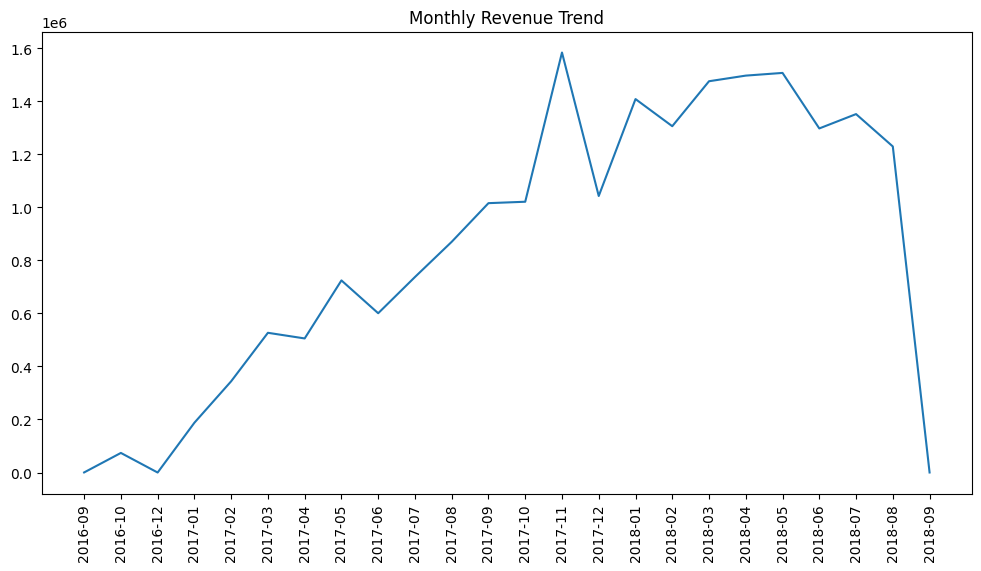

In [128]:
#Monthly Revenue Trend

plt.figure(figsize=(12,6))
plt.plot(monthly_kpis['order_month'].astype(str),monthly_kpis['revenue'])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.show()

### Revenue Trend Analysis

Monthly revenue demonstrates strong marketplace expansion throughout the observation period. Revenue increased from approximately 188 thousand in early 2017 to more than 1.5 million at its peak, representing substantial growth in transaction volume and marketplace activity.

The growth trajectory is not perfectly linear. Several temporary declines are visible, particularly around mid-2017 and after the November 2017 peak. However, the overall trend remains strongly positive, indicating sustained marketplace expansion rather than short-lived growth.

The most notable feature of the revenue series is a significant spike during November 2017, when revenue exceeded 1.58 million. This pattern is consistent with seasonal e-commerce effects such as Black Friday promotions and increased holiday shopping activity.

Following this peak, revenue stabilizes within a range of approximately 1.3–1.5 million per month. This suggests that the marketplace may have transitioned from an early rapid-growth phase toward a more mature operating scale.


###  3.2 Revenue Growth Decomposition

Is revenue growing because:
More customers?
OR
Higher spending per customer?
OR
More orders?

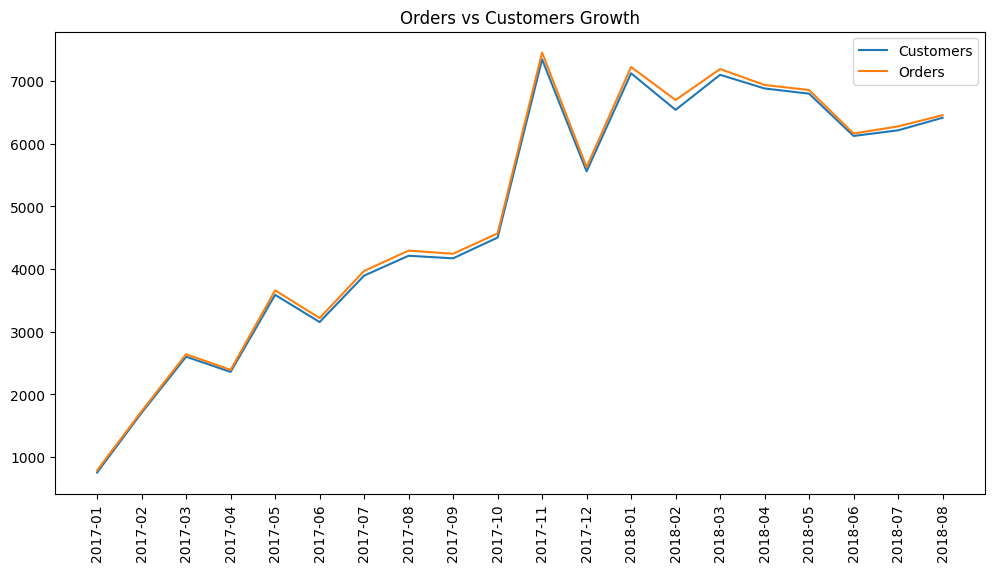

In [129]:
monthly_kpis_analysis = monthly_kpis[~monthly_kpis['order_month'].astype(str).isin(
        ['2016-09', '2016-10', '2016-12', '2018-09'])].copy()

plt.figure(figsize=(12,6))
plt.plot(monthly_kpis_analysis['order_month'].astype(str),monthly_kpis_analysis['customers'],label='Customers')
plt.plot(monthly_kpis_analysis['order_month'].astype(str),monthly_kpis_analysis['orders'],label='Orders')
plt.legend()
plt.xticks(rotation=90)
plt.title('Orders vs Customers Growth')
plt.show()

### Growth Decomposition: Orders vs Customers

Order volume and customer volume move almost identically throughout the observation period. The close alignment between these metrics indicates that marketplace growth is primarily driven by customer acquisition rather than increasing purchase frequency among existing customers.

This finding is consistent with the previously observed repeat-purchase rate, which suggests that most customers place a single order during the observation period. As a result, revenue growth appears to depend heavily on attracting new customers rather than expanding customer lifetime value through retention and repeat purchasing.

From a strategic perspective, customer retention may represent a larger growth opportunity than customer acquisition, since increasing repeat purchasing could generate incremental revenue without requiring proportional increases in marketing spend.

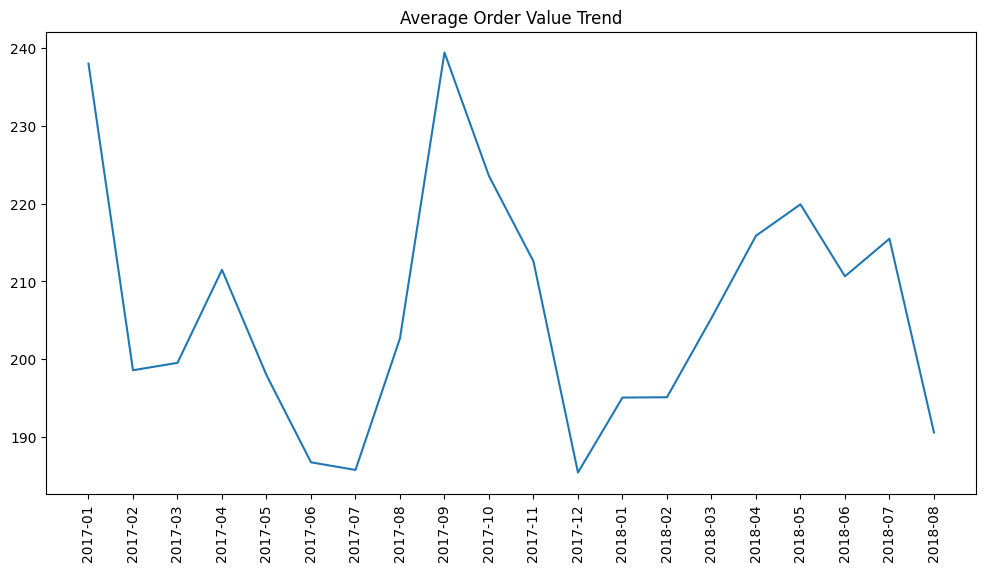

In [130]:
plt.figure(figsize=(12,6))
plt.plot( monthly_kpis_analysis['order_month'].astype(str), monthly_kpis_analysis['aov'])
plt.xticks(rotation=90)
plt.title('Average Order Value Trend')
plt.show()

### Average Order Value Analysis

Average Order Value (AOV) remains relatively stable throughout the observation period, generally fluctuating between 185 and 240 currency units per order.

Although short-term spikes are visible, particularly around late 2017, there is no evidence of a sustained upward trend in customer spending per transaction. This indicates that marketplace revenue growth is not being driven by increasing basket sizes or higher spending behavior.

Combined with the customer-growth analysis, these findings suggest that revenue expansion is primarily attributable to growth in customer acquisition rather than improvements in spending intensity or purchase frequency.

In [131]:
# Revenue Seasonality Analysis
monthly_kpis_analysis['month_num'] = (monthly_kpis_analysis['order_month'].astype(str).str[-2:])

seasonality = (monthly_kpis_analysis.groupby('month_num')['revenue'].mean().sort_values(ascending=False))

seasonality

month_num
11    1583869.010
05    1115739.695
08    1049874.810
07    1044499.210
12    1042855.860
10    1021169.270
09    1015849.570
03    1001280.805
04    1001238.525
06     949174.040
02     825091.795
01     798072.530
Name: revenue, dtype: float64

### Revenue Seasonality Analysis

Revenue exhibits clear seasonal patterns throughout the year.

November generates the highest average monthly revenue, significantly outperforming all other months. This pattern is consistent with major e-commerce events such as Black Friday and holiday-related purchasing activity.

The final quarter of the year (October–December) consistently produces stronger revenue performance than most other periods, indicating the presence of seasonal demand effects.

Conversely, January and February represent the weakest revenue months in the dataset. This decline likely reflects post-holiday reductions in consumer spending and lower marketplace activity.

These findings suggest that future forecasting models should explicitly account for seasonality rather than assuming constant month-to-month growth.

# 4. Customer Behavior Analysis

### 4.1 Customer Purchase Frequency

In [132]:
customer_orders = (master.groupby('customer_unique_id')['order_id'].nunique())

customer_orders.describe()

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

In [133]:
customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [134]:
customer_orders.value_counts().sort_index().head(15)

order_id
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

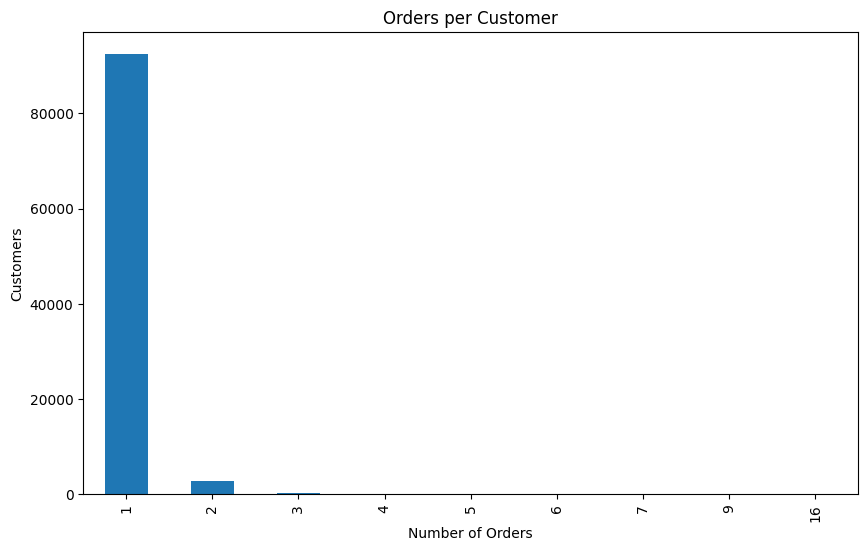

In [135]:
plt.figure(figsize=(10,6))
customer_orders.value_counts().sort_index().head(10).plot(kind='bar')
plt.title('Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Customers')
plt.show()

### 4.2 Repeat Customer Rate

In [136]:
repeat_rate = ((customer_orders > 1).mean()) * 100

print( f"Repeat Customer Rate: {repeat_rate:.2f}%")

Repeat Customer Rate: 3.05%


### Customer Purchase Frequency Analysis

Customer purchasing behavior is heavily concentrated around a single transaction. The median customer places only one order, and the 75th percentile remains at one order, indicating that most marketplace users purchase only once during the observation period.

The average number of orders per customer is approximately 1.03, further confirming that repeat purchasing is relatively uncommon. However, a small group of highly engaged customers exists, with the most active customer placing 16 orders.

The observed repeat purchase rate is approximately 3.05%. This metric should be interpreted cautiously because the dataset represents a fixed observation window rather than complete customer lifetimes. Customers acquired near the end of the observation period had limited opportunity to place additional orders.

Nevertheless, the results suggest that marketplace growth is driven primarily by customer acquisition rather than repeat purchasing behavior.

### 4.3 Revenue Concentration Analysis
Do a small number of customers generate most revenue?

In [137]:
customer_revenue = (master.groupby('customer_unique_id')['total_payment_value'].sum().sort_values(ascending=False))

Top 10 Customers

In [138]:
customer_revenue.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: total_payment_value, dtype: float64

In [139]:
top_10_pct = (customer_revenue.head(10).sum()/customer_revenue.sum()) * 100

print(f"Top 10 Customers Revenue Share: {top_10_pct:.2f}%")

Top 10 Customers Revenue Share: 1.92%


### Revenue Concentration Analysis

Revenue concentration is relatively low across the customer base. The ten highest-spending customers account for only 1.92% of total marketplace revenue.

This suggests that revenue generation is broadly distributed across the customer population rather than being concentrated among a small group of high-value users.

From a business-risk perspective, this is a positive signal because marketplace performance is not heavily dependent on a limited number of customers. However, it also implies that revenue growth will likely require either acquiring more customers or increasing repeat purchase behavior across a large portion of the user base rather than focusing exclusively on a small VIP segment.

### 4.4 Customer Lifetime Value Proxy

In [140]:
customer_summary = ( master.groupby('customer_unique_id').agg(
        total_orders=('order_id', 'nunique'),
        total_revenue=('total_payment_value','sum'),
        avg_review_score=('review_score','mean')
    ).reset_index()
)

customer_summary.head()

,customer_unique_id,total_orders,total_revenue,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0
2,0000f46a3911fa3c0805444483337064,1,86.22,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.0


In [141]:
customer_summary.sort_values('total_revenue',ascending=False).head(10)

,customer_unique_id,total_orders,total_revenue,avg_review_score
3799,0a0a92112bd4c708ca5fde585afaa872,1,109312.64,1.0
39443,698e1cf81d01a3d389d96145f7fa6df8,1,45256.00,NaN
73155,c402f431464c72e27330a67f7b94d4fb,1,44048.00,1.0
23947,4007669dec559734d6f53e029e360987,1,36489.24,1.0
89365,ef8d54b3797ea4db1d63f0ced6a906e9,1,30186.00,5.0
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,29099.52,1.0
74752,c8460e4251689ba205045f3ea17884a1,4,27935.46,4.0
87642,eae0a83d752b1dd32697e0e7b4221656,2,25051.89,3.0
22910,3d47f4368ccc8e1bb4c4a12dbda7111b,1,22346.60,1.0
64943,adfa1cab2b2c8706db21bb13c0a1beb1,1,19457.04,3.0


## Customer Analysis Summary

Customer behavior indicates that marketplace growth is primarily acquisition-driven. Most customers place a single order during the observation period, while repeat purchasing remains relatively uncommon.

Revenue concentration is low, suggesting that marketplace performance is not dependent on a small number of high-spending customers. Instead, revenue is generated across a broad customer base.

These findings imply that future growth opportunities may lie in improving customer retention, increasing repeat purchasing behavior, and enhancing customer lifetime value rather than relying solely on customer acquisition.

# 5. Delivery Performance Analysis

In [142]:
# DELIVERY PERFORMANCE OVERVIEW

delivery_summary = (master['delivery_days'].describe())
delivery_summary

count    110196.000000
mean         12.472631
std           9.445655
min           0.533414
25%           6.736262
50%          10.184282
75%          15.541097
max         209.628611
Name: delivery_days, dtype: float64

In [143]:
master['delivery_days'].median()

10.184282407407409

In [144]:
master['delivery_days'].skew()

np.float64(3.8392523909847447)

In [145]:
master['delivery_days'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25     6.736262
0.50    10.184282
0.75    15.541097
0.90    22.921071
0.95    29.058967
0.99    45.805398
Name: delivery_days, dtype: float64

### Delivery Time Distribution

Delivery times exhibit strong positive skewness (3.84), indicating that while most customers receive their orders within a relatively predictable timeframe, a small number of orders experience substantial delays.

The median delivery duration is 10.18 days, compared with a mean delivery duration of 12.47 days. The difference between these measures suggests that extreme delays inflate average delivery times and that median-based metrics provide a more representative view of the typical customer experience.

### 5.2 Delivery Distribution

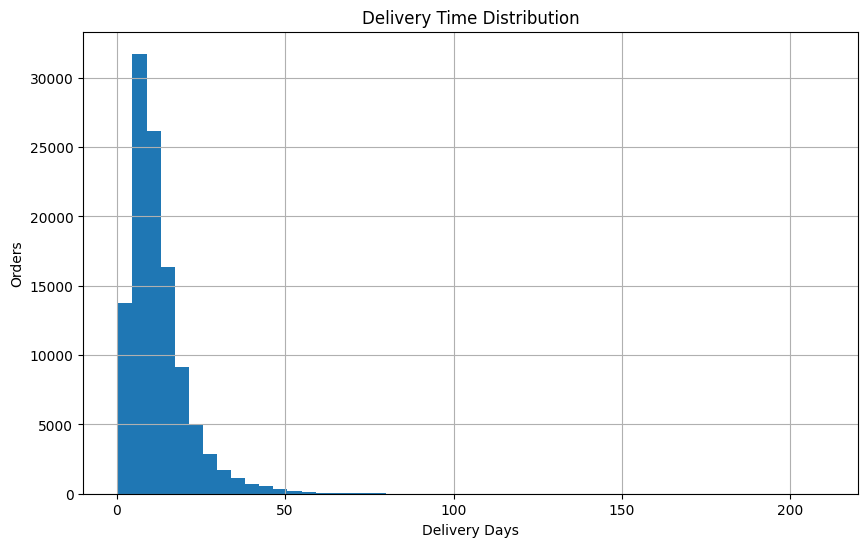

In [146]:
plt.figure(figsize=(10,6))
master['delivery_days'].hist(bins=50)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Days')
plt.ylabel('Orders')
plt.show()

### 5.3 On-Time Delivery Analysis

In [147]:
on_time_rate = (master['on_time_delivery'].mean()) * 100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

On-Time Delivery Rate: 90.09%


In [148]:
late_rate = ((master['on_time_delivery'] == 0).mean()) * 100

print( f"Late Delivery Rate: {late_rate:.2f}%")

Late Delivery Rate: 9.91%


### Delivery Reliability

Operational reliability is strong across the marketplace. More than 90% of deliveries arrive on or before the promised delivery date, while fewer than 10% arrive late.

This finding suggests that customer expectations are generally managed effectively. Although delivery durations are not exceptionally short, the marketplace consistently delivers within communicated timeframes, which likely contributes to the strong customer satisfaction scores observed earlier.

### 5.4 Delivery Promise Gap

In [149]:
master['delivery_promise_gap_days'].describe()

count    110196.000000
mean        -11.333149
std          10.162342
min        -146.016123
25%         -16.321042
50%         -12.046788
75%          -6.476803
max         188.975081
Name: delivery_promise_gap_days, dtype: float64

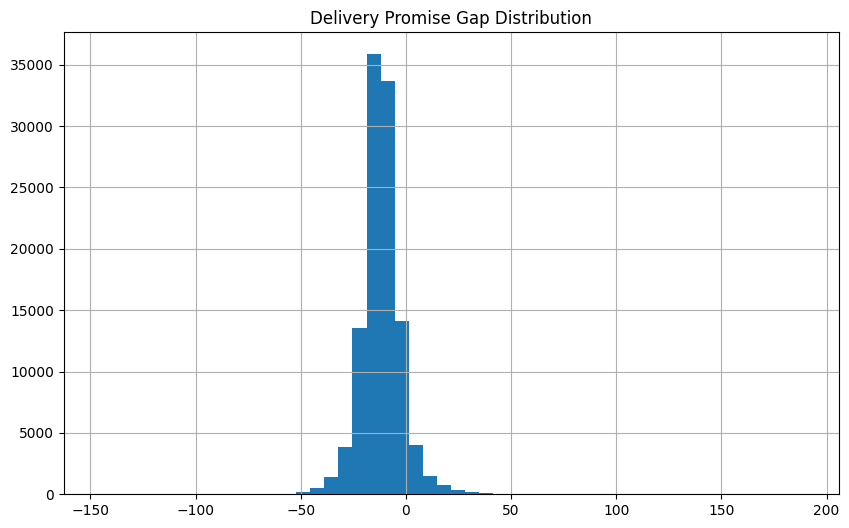

In [150]:
plt.figure(figsize=(10,6))
master['delivery_promise_gap_days'].hist( bins=50)
plt.title('Delivery Promise Gap Distribution')
plt.show()

### 6.5 Delivery Performance by State

In [151]:
state_delivery = (master.groupby('customer_state').agg(
        avg_delivery_days=('delivery_days','mean'),
        on_time_rate=('on_time_delivery','mean')
    ).sort_values('avg_delivery_days',ascending = True))

state_delivery.head(10)

,avg_delivery_days,on_time_rate
customer_state,,
SP,8.723795,0.922338
PR,11.947217,0.937108
MG,11.983906,0.930231
DF,12.958993,0.906068
SC,15.001540,0.886973
RJ,15.148467,0.844434
RS,15.188566,0.915958
GO,15.403338,0.899271
MS,15.534072,0.882784


In [152]:
# worst states 
state_delivery.tail(10)

,avg_delivery_days,on_time_rate
customer_state,,
PB,20.589148,0.863787
AC,20.715550,0.956522
CE,20.987465,0.817321
SE,21.467353,0.815584
MA,21.648667,0.773058
PA,23.754053,0.854630
AL,24.489142,0.729730
AM,26.390967,0.945455
AP,28.205960,0.939024


### 5.6 Seller Fulfillment vs Carrier Performance

In [153]:
master[['approval_latency_days',
        'carrier_handoff_days',
        'carrier_transit_days',
        'delivery_days']].median()

approval_latency_days     0.014606
carrier_handoff_days      1.870608
carrier_transit_days      7.059144
delivery_days            10.184282
dtype: float64

### Delivery Reliability

Operational reliability is strong across the marketplace. More than 90% of deliveries arrive on or before the promised delivery date, while fewer than 10% arrive late.

This finding suggests that customer expectations are generally managed effectively. Although delivery durations are not exceptionally short, the marketplace consistently delivers within communicated timeframes, which likely contributes to the strong customer satisfaction scores observed earlier.

In [154]:
master.groupby('delivery_speed_group')['review_score'].agg(['count','mean','median'])

,count,mean,median
delivery_speed_group,,,
fast,54787,4.300108,5.0
slow,54582,3.862574,5.0


# 6. Customer Satisfaction Analysis

## 6.1 Review Score Distribution

### How satisfied are customers overall?

In [155]:
master['review_score'].describe()

count    111708.000000
mean          4.032854
std           1.387526
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

### Review Score Distribution

Customer satisfaction appears generally strong across the marketplace. The average review score is 4.03 out of 5, indicating that customers report positive experiences overall.

The median review score is 5, meaning that at least half of all reviews award the maximum possible rating. Furthermore, 75% of reviews are 4 stars or higher, demonstrating that positive customer experiences are common throughout the marketplace.

However, the standard deviation of 1.39 indicates that customer experiences are not entirely uniform. While most customers are highly satisfied, a meaningful subset of orders receives substantially lower ratings. Identifying the operational factors associated with these lower ratings represents an important opportunity for improvement.

These findings suggest that the marketplace delivers a generally strong customer experience but still contains pockets of dissatisfaction that warrant further investigation.

In [156]:
master['review_score'].value_counts().sort_index()

review_score
1.0    14142
2.0     3843
3.0     9375
4.0    21191
5.0    63157
Name: count, dtype: int64

In [157]:
total_valid_reviews = master['review_score'].count()

for score, count in master['review_score'].value_counts().items():
    percentage = (count * 100) / total_valid_reviews
    print(f"Review Score {score}: {percentage:.2f}% ({count} reviews)")

Review Score 5.0: 56.54% (63157 reviews)
Review Score 4.0: 18.97% (21191 reviews)
Review Score 1.0: 12.66% (14142 reviews)
Review Score 3.0: 8.39% (9375 reviews)
Review Score 2.0: 3.44% (3843 reviews)


### Review Score Distribution

Customer satisfaction is generally strong across the marketplace. More than 75% of all reviews are either 4-star or 5-star ratings, indicating that most customers report positive experiences.

The most common rating is 5 stars, representing 56.5% of all reviews. This suggests that a majority of customers are highly satisfied with their purchases.

However, an important pattern emerges at the lower end of the distribution. Approximately 12.7% of all reviews are 1-star ratings, making them significantly more common than either 2-star or 3-star reviews.

This distribution indicates that customer sentiment is somewhat polarized. Most customers have excellent experiences, while a meaningful minority experience severe dissatisfaction. The results suggest that improving specific operational failure points may have a larger impact on customer satisfaction than attempting incremental improvements to already-successful orders.

<Axes: xlabel='review_score'>

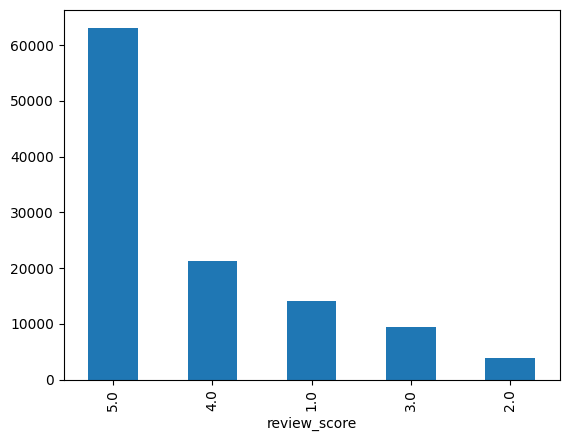

In [158]:
master['review_score'].value_counts().plot(kind='bar')

## 6.2 Delivery Speed vs Satisfaction

In [159]:
master.groupby("delivery_speed_group")["review_score"].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_speed_group,,,,,,,,
fast,54787.0,4.300108,1.186368,1.0,4.0,5.0,5.0,5.0
slow,54582.0,3.862574,1.458866,1.0,3.0,5.0,5.0,5.0


### Delivery Speed and Customer Satisfaction

Customer satisfaction differs meaningfully between fast and slow deliveries.

Orders classified as fast deliveries achieve an average review score of 4.30, compared with 3.86 for slow deliveries. The observed difference of approximately 0.44 review points suggests that delivery speed has a substantial relationship with customer experience.

Although both groups share the same median review score of 5, the mean scores reveal a clear shift toward higher customer satisfaction among fast deliveries.

Additionally, slow deliveries exhibit greater variability in review scores (standard deviation = 1.46) compared with fast deliveries (standard deviation = 1.19). This indicates that slower deliveries produce less predictable customer experiences and increase the likelihood of poor reviews.

These findings provide preliminary evidence that delivery performance may be a key driver of customer satisfaction and justify formal statistical testing.

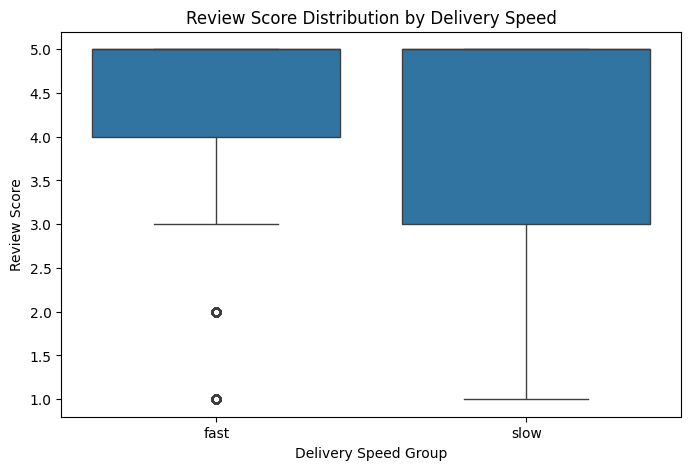

In [160]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.boxplot(x='delivery_speed_group',
    y='review_score',
    data=master)

plt.title('Review Score Distribution by Delivery Speed')

plt.xlabel('Delivery Speed Group')
plt.ylabel('Review Score')

plt.show()

In [161]:
review_dist = pd.crosstab(master['delivery_speed_group'],master['review_score'],normalize='index') * 100
review_dist

review_score,1.0,2.0,3.0,4.0,5.0
delivery_speed_group,,,,,
fast,7.510906,2.626535,6.925000,18.216000,64.721558
slow,15.345718,4.085596,9.897036,20.308893,50.362757


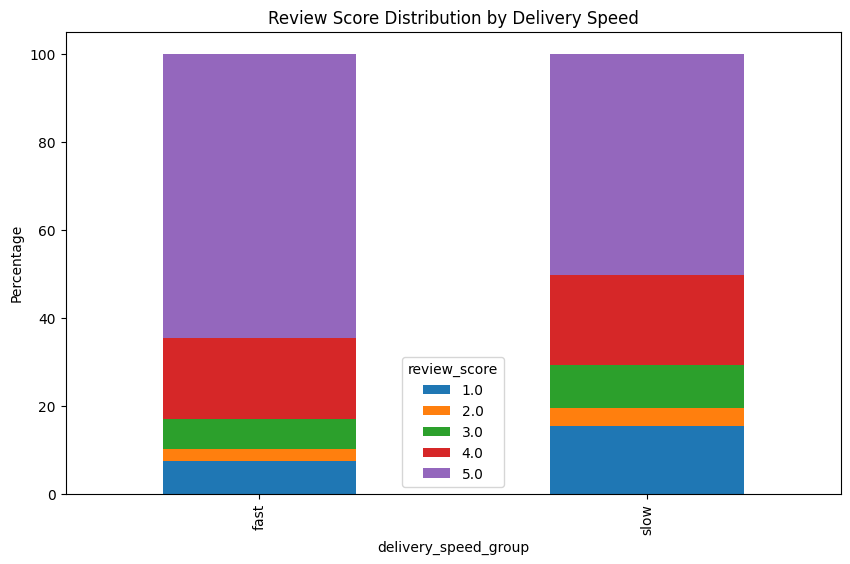

In [162]:
review_dist.plot(kind='bar',stacked=True,figsize=(10,6))
plt.title('Review Score Distribution by Delivery Speed')
plt.ylabel('Percentage')
plt.show()

## 6.3 Fast vs Slow Delivery Hypothesis Test

## Hypothesis Formulation

### Null Hypothesis (H₀)

The distribution of review scores is identical between fast-delivery and slow-delivery orders.

There is no statistically significant difference in customer satisfaction between the two delivery groups.

### Alternative Hypothesis (H₁)

The distribution of review scores differs between fast-delivery and slow-delivery orders.

Delivery speed has a statistically significant relationship with customer satisfaction.

In [163]:
# CREATE COMPARISON GROUPS
fast_reviews = master.loc[master['delivery_speed_group'] == 'fast','review_score'].dropna()

slow_reviews = master.loc[master['delivery_speed_group'] == 'slow','review_score'].dropna()

print("Fast reviews:", len(fast_reviews))
print("Slow reviews:", len(slow_reviews))

Fast reviews: 54787
Slow reviews: 54582


## We are doing Mann-Whitney U Instead of a t-Test

Review scores are measured on an ordinal 1–5 scale and are not normally distributed.

Earlier exploratory analysis showed:

- Strong concentration of 5-star ratings
- Significant ceiling effect
- Non-normal distribution

Therefore, a non-parametric test is more appropriate than a classical t-test.

The Mann-Whitney U test compares the distributions of two independent groups without assuming normality.

In [164]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(fast_reviews,slow_reviews,alternative='two-sided')

print(f"U Statistic : {u_stat:,.0f}")
print(f"P-value     : {p_value:.10f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

U Statistic : 1,744,508,830
P-value     : 0.0000000000
Reject H0


## Effect Size Analysis

Statistical significance only indicates whether an effect exists.

Effect size measures the magnitude of the effect and helps determine whether the difference is meaningful from a business perspective.

Cohen's d is used to quantify the standardized difference between the two groups.

In [165]:
mean_fast = fast_reviews.mean()
mean_slow = slow_reviews.mean()

std_fast = fast_reviews.std()
std_slow = slow_reviews.std()

n_fast = len(fast_reviews)
n_slow = len(slow_reviews)

pooled_std = np.sqrt((((n_fast - 1) * std_fast**2) +((n_slow - 1) * std_slow**2))/(n_fast + n_slow - 2))

cohens_d = (mean_fast - mean_slow) / pooled_std

print(f"Cohen's d = {cohens_d:.4f}")

if abs(cohens_d) < 0.20:
    interpretation = "Negligible"

elif abs(cohens_d) < 0.50:
    interpretation = "Small"

elif abs(cohens_d) < 0.80:
    interpretation = "Medium"

else:
    interpretation = "Large"

print(f"Effect Size Interpretation: {interpretation}")

Cohen's d = 0.3291
Effect Size Interpretation: Small


## Statistical Test Results

A Mann-Whitney U test was conducted to compare review scores between fast-delivery and slow-delivery orders.

The test produced an extremely small p-value (p < 0.001), leading to rejection of the null hypothesis. This indicates that the distribution of customer review scores differs significantly between the two delivery groups.

To assess practical significance, Cohen's d was calculated. The resulting effect size of 0.329 indicates a small but meaningful effect according to conventional benchmarks.

While the effect size is not large, the difference is operationally important because it is observed across more than 100,000 orders. Fast deliveries achieve an average review score of 4.30 compared with 3.86 for slow deliveries, representing an improvement of approximately 0.44 review points.

These findings suggest that delivery speed is a meaningful driver of customer satisfaction and that investments aimed at reducing delivery times may improve overall customer experience at scale.

### Executive Recommendation

Delivery speed should be treated as a strategic customer experience metric rather than solely an operational efficiency metric.

The analysis demonstrates that customers receiving faster deliveries report significantly higher satisfaction levels. Because carrier transit time represents the largest component of the delivery lifecycle, logistics optimization initiatives should focus primarily on transportation efficiency rather than payment approval workflows.

Potential improvement opportunities include carrier performance management, regional fulfillment optimization, and inventory placement strategies designed to reduce transit times.

## 6.4 On-Time vs Late Deliveries

In [166]:
master.groupby('on_time_delivery')['review_score'].describe()

,count,mean,std,min,25%,50%,75%,max
on_time_delivery,,,,,,,,
False,10859.0,2.374896,1.626781,1.0,1.0,1.0,4.0,5.0
True,100849.0,4.211375,1.232779,1.0,4.0,5.0,5.0,5.0


### On-Time Delivery and Customer Satisfaction

A substantial difference in customer satisfaction exists between on-time and late deliveries.

Orders delivered on or before the promised date achieve an average review score of 4.21, whereas late deliveries achieve an average review score of only 2.37.

The observed difference of approximately 1.84 review points is substantially larger than the difference observed between fast and slow deliveries. This suggests that delivery reliability may be a stronger driver of customer satisfaction than delivery speed itself.

These findings indicate that customers are generally willing to tolerate longer delivery durations when expectations are managed effectively. However, failing to meet the promised delivery date has a severe negative impact on customer experience.

From a business perspective, improving delivery predictability may generate greater customer satisfaction gains than focusing exclusively on reducing delivery times.

### Null Hypothesis (H₀)

Review score distributions are identical between on-time and late deliveries.

### Alternative Hypothesis (H₁)

Review score distributions differ between on-time and late deliveries.

In [167]:
on_time_reviews = master.loc[master['on_time_delivery'] == True,'review_score'].dropna()

late_reviews = master.loc[ master['on_time_delivery'] == False,'review_score'].dropna()

print("On-Time Reviews:", len(on_time_reviews))
print("Late Reviews:", len(late_reviews))

On-Time Reviews: 100849
Late Reviews: 10859


In [168]:
u_stat, p_value = mannwhitneyu(
    on_time_reviews,
    late_reviews,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:,.0f}")
print(f"P-value: {p_value:.20f}")
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

U Statistic: 863,420,082
P-value: 0.00000000000000000000
Reject H0


In [169]:
mean_on_time = on_time_reviews.mean()
mean_late = late_reviews.mean()

std_on_time = on_time_reviews.std()
std_late = late_reviews.std()

n1 = len(on_time_reviews)
n2 = len(late_reviews)

pooled_std = np.sqrt(
    (((n1 - 1) * std_on_time**2)+((n2 - 1) * std_late**2))
    /(n1 + n2 - 2)
)

cohens_d = (mean_on_time - mean_late) / pooled_std

print(f"Cohen's d = {cohens_d:.4f}")
if abs(cohens_d) < 0.20:
    print("Negligible Effect")

elif abs(cohens_d) < 0.50:
    print("Small Effect")

elif abs(cohens_d) < 0.80:
    print("Medium Effect")

else:
    print("Large Effect")

Cohen's d = 1.4388
Large Effect


## Statistical Test: On-Time vs Late Deliveries

A Mann-Whitney U test was conducted to compare review scores between orders delivered on time and orders delivered after the promised delivery date.

The test produced an extremely small p-value (p < 0.001), leading to rejection of the null hypothesis. This indicates that customer satisfaction differs significantly between the two delivery groups.

Effect size analysis revealed a Cohen's d value of 1.44, representing an exceptionally large practical effect. This effect is substantially larger than the effect observed when comparing fast versus slow deliveries.

Orders delivered on time achieve an average review score of 4.21, whereas late deliveries achieve an average review score of only 2.37. The difference of approximately 1.84 review points demonstrates that delivery reliability is one of the strongest drivers of customer satisfaction in the marketplace.

These findings suggest that customers care more about receiving orders when promised than receiving them as quickly as possible.

## 6.5 Delivery Days Correlation

As delivery time increases, does customer satisfaction decrease?
review_score = ordinal (1-5)
delivery_days = continuous
Relationship may not be linear
→ Spearman correlation is appropriate

In [170]:
# 6.5 DELIVERY DAYS CORRELATION

from scipy.stats import spearmanr

corr, p_value = spearmanr(master['delivery_days'], master['review_score'], nan_policy='omit')

print(f"Spearman Correlation: {corr:.4f}")
print(f"P-value: {p_value:.10f}")

Spearman Correlation: -0.2213
P-value: 0.0000000000


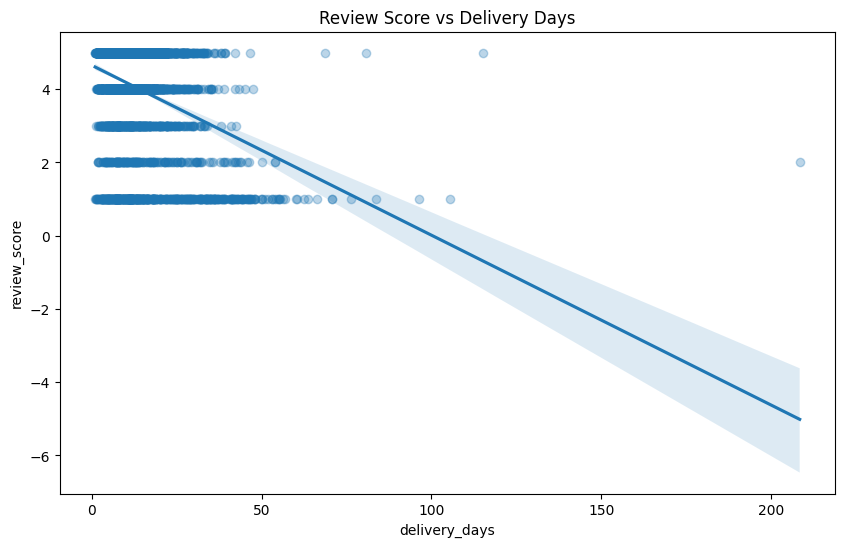

In [171]:
plt.figure(figsize=(10,6))

sample_df = master[['delivery_days', 'review_score']].dropna().sample(n=5000,random_state=42)

sns.regplot(data=sample_df,x='delivery_days',y='review_score',scatter_kws={'alpha':0.3})

plt.title( 'Review Score vs Delivery Days')

plt.show()

## 6.6 Category Satisfaction

Which categories create the happiest and unhappiest customers?

In [172]:
# 6.6 CATEGORY SATISFACTION

category_reviews = (master.groupby('product_category_name_english')
    .agg( orders=('order_id', 'nunique'),
           avg_review_score=('review_score','mean')).reset_index())

category_reviews = category_reviews[category_reviews['orders'] >= 100]

category_reviews = category_reviews.sort_values( 'avg_review_score', ascending=False)

category_reviews.head(10)

,product_category_name_english,orders,avg_review_score
8,books_general_interest,512,4.446266
10,books_technical,260,4.363636
53,luggage_accessories,1034,4.315257
37,food_drink,227,4.310469
31,fashion_shoes,240,4.228682
36,food,450,4.218182
66,stationery,2311,4.196078
60,pet_shop,1710,4.184306
14,computers,181,4.175000
59,perfumery,3162,4.165932


In [173]:
category_reviews.tail(10)

,product_category_name_english,orders,avg_review_score
15,computers_accessories,6689,3.932537
39,furniture_decor,6449,3.906788
40,furniture_living_room,422,3.901606
7,bed_bath_table,9417,3.898470
19,construction_tools_safety,167,3.844560
4,audio,350,3.833333
47,home_confort,397,3.831019
34,fixed_telephony,217,3.681992
30,fashion_male_clothing,112,3.641221
57,office_furniture,1273,3.491950


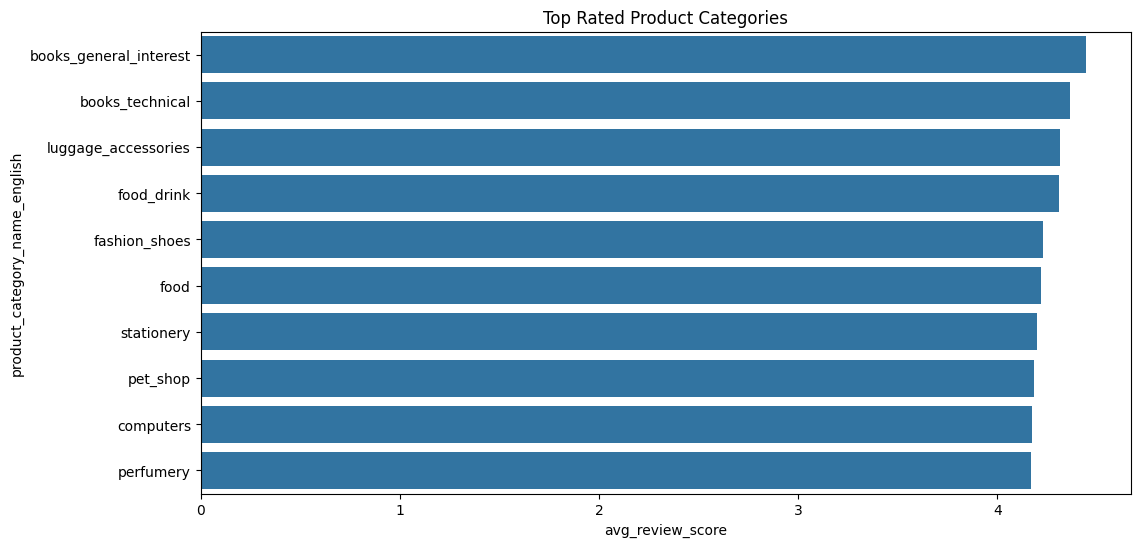

In [174]:
top_categories = category_reviews.head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top_categories, x='avg_review_score',y='product_category_name_english')

plt.title('Top Rated Product Categories')

plt.show()

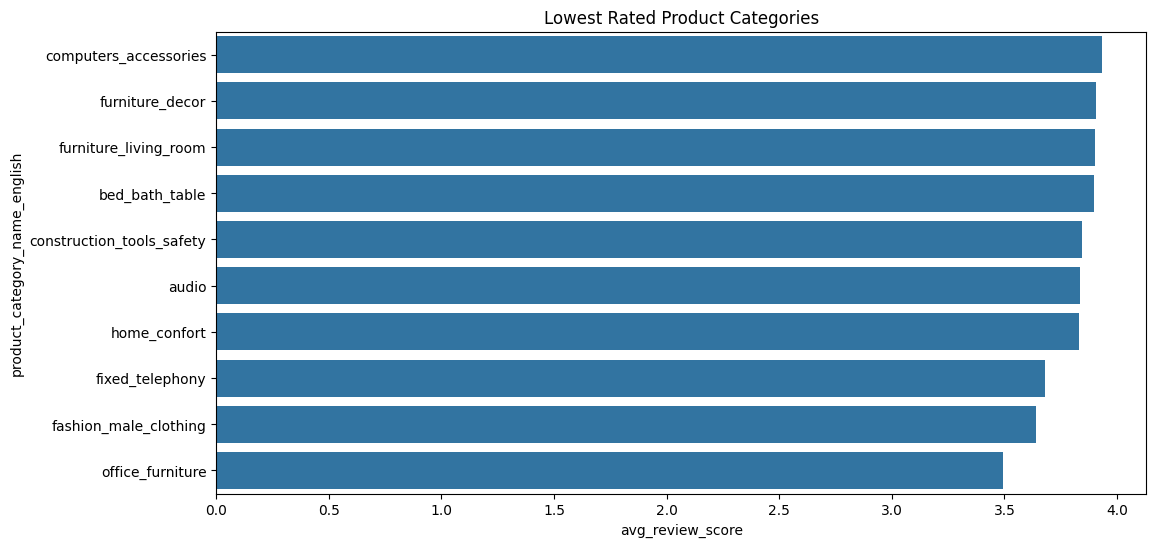

In [175]:
bottom_categories = category_reviews.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(data=bottom_categories,x='avg_review_score',y='product_category_name_english')

plt.title( 'Lowest Rated Product Categories')

plt.show()

## 6.7 State Satisfaction

Which states have the best and worst customer experiences?

In [176]:
# 6.7 STATE SATISFACTION

state_reviews = ( master.groupby('customer_state')
    .agg(orders=('order_id', 'nunique'),
        avg_review_score=('review_score','mean'),
        avg_delivery_days=('delivery_days','mean')
    ).reset_index()
)

state_reviews = state_reviews[state_reviews['orders'] >= 100]

state_reviews.sort_values('avg_review_score',ascending=False).head(10)

,customer_state,orders,avg_review_score,avg_delivery_days
25,SP,41375,4.126825,8.723795
26,TO,279,4.108280,17.448385
17,PR,4998,4.107493,11.947217
2,AM,147,4.092025,26.390967
10,MG,11544,4.085879,11.983906
19,RN,482,4.080000,19.325275
22,RS,5432,4.052953,15.188566
11,MS,709,4.045288,15.534072
20,RO,247,4.021661,19.739366
23,SC,3612,4.004588,15.001540


In [177]:
state_reviews.sort_values('avg_review_score',ascending=True).head(10)

,customer_state,orders,avg_review_score,avg_delivery_days
9,MA,740,3.701711,21.648667
1,AL,411,3.721088,24.489142
13,PA,970,3.791509,23.754053
18,RJ,12762,3.810488,15.148467
5,CE,1327,3.814588,20.987465
4,BA,3358,3.816070,19.247618
24,SE,345,3.835509,21.467353
16,PI,493,3.895717,19.384710
15,PE,1648,3.954036,18.279267
12,MT,903,3.976054,17.961682


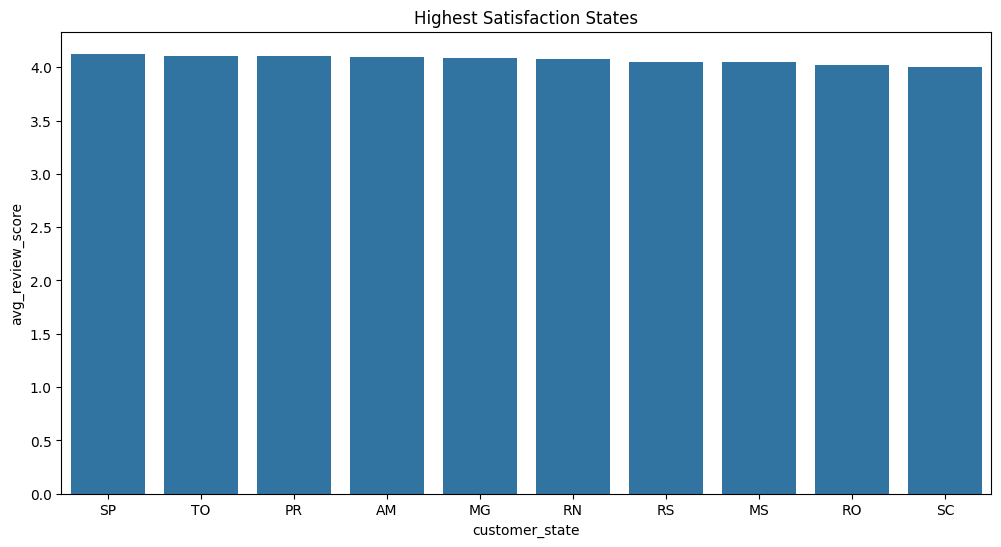

In [178]:
plt.figure(figsize=(12,6))

sns.barplot(data=state_reviews.sort_values('avg_review_score',ascending=False).head(10),
    x='customer_state',
    y='avg_review_score')

plt.title('Highest Satisfaction States')

plt.show()

## 6.8 Seller Satisfaction

Are specific sellers causing poor customer experiences?

In [179]:
# 6.8 SELLER SATISFACTION

seller_reviews = ( master.groupby('seller_id')
    .agg(orders=('order_id', 'nunique'),
         avg_review_score=( 'review_score','mean')).reset_index())

seller_reviews = seller_reviews[seller_reviews['orders'] >= 20]

In [180]:
seller_reviews.sort_values('avg_review_score',ascending=False).head(10)

,seller_id,orders,avg_review_score
863,48efc9d94a9834137efd9ea76b065a38,33,5.000000
786,41c2bad7229b0c25e6becf179ebf63ff,20,4.956522
35,02f5837340d7eb4f653d676c7256523a,30,4.833333
2629,d9bd94811c3338dceb4181f3dbc0c73e,54,4.819672
2531,d13e50eaa47b4cbe9eb81465865d8cfc,67,4.811594
799,42fa4ee7240e9b8eb4576358ec142ba7,22,4.809524
1515,7ade73f1b9b4e965f9009a4c3a7e2c15,27,4.777778
651,3785b653b1b82de85ab47dd139938091,21,4.750000
1624,83e197e95a1bbabc8c75e883ed016c47,47,4.745455
15,013900e863eace745d3ec7614cab5b1a,23,4.730769


In [181]:
seller_reviews.sort_values('avg_review_score',ascending=True).head(10)

,seller_id,orders,avg_review_score
809,4342d4b2ba6b161468c63a7e7cfce593,20,1.263158
3094,ffff564a4f9085cd26170f4732393726,20,2.100000
333,1ca7077d890b907f89be8c954a02686a,115,2.198529
464,2709af9587499e95e803a6498a5a56e9,26,2.565217
554,2eb70248d66e0e3ef83659f71b244378,202,2.716346
2132,b19f3ca2ea475913750f25a5c37c8d8f,24,2.791667
1178,602044f2c16190c2c6e45eb35c2e21cb,50,2.892857
1032,54965bbe3e4f07ae045b90b0b8541f52,78,2.938272
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,98,2.952830
1846,972d0f9cf61b499a4812cf0bfa3ad3c4,83,2.964286


## 6.9 What Drives Satisfaction?

In [182]:
# 6.9 WHAT DRIVES SATISFACTION?

driver_cols = ['review_score',
    'delivery_days',
    'delivery_promise_gap_days',
    'carrier_transit_days',
    'carrier_handoff_days',
    'approval_latency_days',
    'total_payment_value',
    'freight_value',
    'product_weight_g']

driver_df = master[driver_cols].copy()

In [183]:
corr_matrix = driver_df.corr(method='spearman')

corr_matrix

,review_score,delivery_days,delivery_promise_gap_days,carrier_transit_days,carrier_handoff_days,approval_latency_days,total_payment_value,freight_value,product_weight_g
review_score,1.000000,-0.221332,-0.152084,-0.179323,-0.106222,-0.014461,-0.077164,-0.045723,-0.016939
delivery_days,-0.221332,1.000000,0.308207,0.884440,0.386611,0.092967,0.135305,0.423040,0.100450
delivery_promise_gap_days,-0.152084,0.308207,1.000000,0.227470,0.170028,0.061305,-0.068517,-0.144269,-0.008496
carrier_transit_days,-0.179323,0.884440,0.227470,1.000000,0.038073,0.015244,0.111965,0.458173,0.070668
carrier_handoff_days,-0.106222,0.386611,0.170028,0.038073,1.000000,-0.050228,0.065967,0.038699,0.080706
approval_latency_days,-0.014461,0.092967,0.061305,0.015244,-0.050228,1.000000,0.021584,0.029673,0.002120
total_payment_value,-0.077164,0.135305,-0.068517,0.111965,0.065967,0.021584,1.000000,0.455154,0.489873
freight_value,-0.045723,0.423040,-0.144269,0.458173,0.038699,0.029673,0.455154,1.000000,0.446591
product_weight_g,-0.016939,0.100450,-0.008496,0.070668,0.080706,0.002120,0.489873,0.446591,1.000000


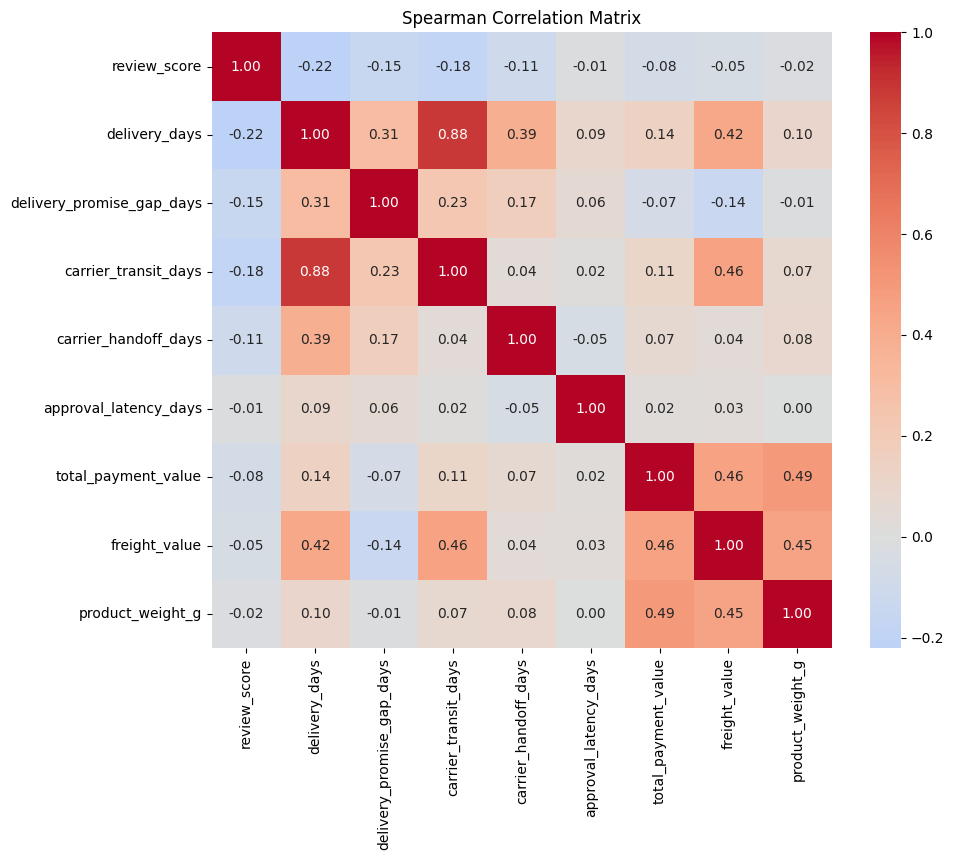

In [184]:
plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',center=0)

plt.title( 'Spearman Correlation Matrix')

plt.show()

In [185]:
corr_matrix['review_score'].sort_values(ascending=False)

review_score                 1.000000
approval_latency_days       -0.014461
product_weight_g            -0.016939
freight_value               -0.045723
total_payment_value         -0.077164
carrier_handoff_days        -0.106222
delivery_promise_gap_days   -0.152084
carrier_transit_days        -0.179323
delivery_days               -0.221332
Name: review_score, dtype: float64

# 6.10 Executive Satisfaction Summary

## Objective

The purpose of this analysis was to identify the primary drivers of customer satisfaction and determine which operational improvements would generate the greatest impact on the customer experience.

---

## Key Findings

### 1. Overall Customer Satisfaction Is Strong

The marketplace maintains a healthy customer experience, with an average review score of 4.03 out of 5.

More than 75% of all reviews are either 4-star or 5-star ratings, indicating that most customers report positive experiences.

However, approximately 12.7% of reviews are 1-star ratings, suggesting that while most orders succeed, a meaningful subset of customers experience severe dissatisfaction.

---

### 2. Delivery Reliability Is the Strongest Driver of Satisfaction

Orders delivered on time achieve an average review score of 4.21, whereas late deliveries achieve an average review score of only 2.37.

A Mann–Whitney U test confirmed that the difference is statistically significant (p < 0.001), and effect size analysis produced a Cohen's d of 1.44, representing an exceptionally large practical effect.

This finding demonstrates that customers care more about receiving orders when promised than receiving them as quickly as possible.

---

### 3. Delivery Speed Matters, But Less Than Reliability

Fast deliveries achieve an average review score of 4.30 compared with 3.86 for slow deliveries.

Although the relationship is statistically significant, the practical effect size (Cohen's d = 0.33) is considerably smaller than the on-time versus late delivery effect.

This indicates that reducing delivery times can improve customer satisfaction, but ensuring delivery commitments are met should be the higher operational priority.

---

### 4. Logistics Performance Drives Customer Experience

Correlation analysis shows that delivery-related variables exhibit the strongest relationships with review scores.

The most influential factors include:

- Delivery duration
- Carrier transit time
- Delivery promise gap

Pricing-related variables such as payment value and freight cost demonstrate substantially weaker relationships with customer satisfaction.

These results suggest that customer satisfaction is primarily an operational challenge rather than a pricing challenge.

---

### 5. Carrier Transit Represents the Largest Operational Bottleneck

Delivery lifecycle decomposition revealed:

| Stage | Median Days |
|---------|---------:|
| Payment Approval | 0.01 |
| Seller Handoff | 1.87 |
| Carrier Transit | 7.06 |
| Total Delivery | 10.18 |

Approximately 70% of the total delivery lifecycle occurs after the package enters the carrier network.

This indicates that transportation and logistics operations represent the largest opportunity for customer experience improvement.

---

### 6. Satisfaction Varies Across Categories and Regions

Certain product categories consistently achieve higher customer satisfaction scores, particularly books, luggage accessories, and food-related categories.

Regional analysis also shows that states with shorter delivery durations generally achieve higher review scores, providing further evidence that logistics performance influences customer perception.

---

## Executive Recommendations

### Priority 1: Reduce Late Deliveries

Late deliveries have the largest observed impact on customer satisfaction.

Operational initiatives should focus on:

- Carrier performance monitoring
- Route optimization
- Delivery forecasting improvements
- Proactive delay management

---

### Priority 2: Improve Delivery Predictability

Customers appear more sensitive to broken delivery promises than absolute delivery speed.

Improving delivery date accuracy may generate larger customer satisfaction gains than reducing delivery times alone.

---

### Priority 3: Optimize Logistics Network Performance

Because carrier transit time represents the largest component of the delivery lifecycle, logistics optimization efforts should prioritize transportation efficiency before payment-processing or approval workflow improvements.

---

### Priority 4: Investigate 1-Star Reviews

Although overall satisfaction is high, approximately 12.7% of all reviews are 1-star ratings.

Future analysis should focus on identifying the operational characteristics associated with these extreme negative experiences.

---

## Final Conclusion

The marketplace demonstrates strong overall customer satisfaction and reliable operational performance. However, customer experience is heavily influenced by delivery execution.

The analysis consistently shows that logistics reliability, particularly the ability to meet promised delivery dates, is the single most important driver of customer satisfaction.

Future investments aimed at improving delivery predictability and reducing late deliveries are likely to generate the greatest customer experience improvements and provide the highest business impact.

# 7. Product Category Analysis

The objective of this section is to understand how different product categories contribute to marketplace performance.

Specifically, we aim to identify:

- Which categories generate the most revenue
- Which categories generate the most orders
- Which categories have the highest average order value
- Which categories create the best customer experiences
- Which categories suffer from operational inefficiencies
- Which categories represent the greatest business opportunity

## 7.1 Category Revenue Analysis

In [186]:
category_revenue = (master.groupby('product_category_name_english')
    .agg(revenue=('total_payment_value', 'sum'),
        orders=('order_id', 'nunique')).reset_index().sort_values('revenue', ascending=False)
)

category_revenue.head(10)

,product_category_name_english,revenue,orders
7,bed_bath_table,1712553.67,9417
43,health_beauty,1657373.12,8836
15,computers_accessories,1585330.45,6689
39,furniture_decor,1430176.39,6449
70,watches_gifts,1429216.68,5624
65,sports_leisure,1392127.56,7720
49,housewares,1094758.13,5884
5,auto,852294.33,3897
42,garden_tools,838280.75,3518
20,cool_stuff,779698.00,3632


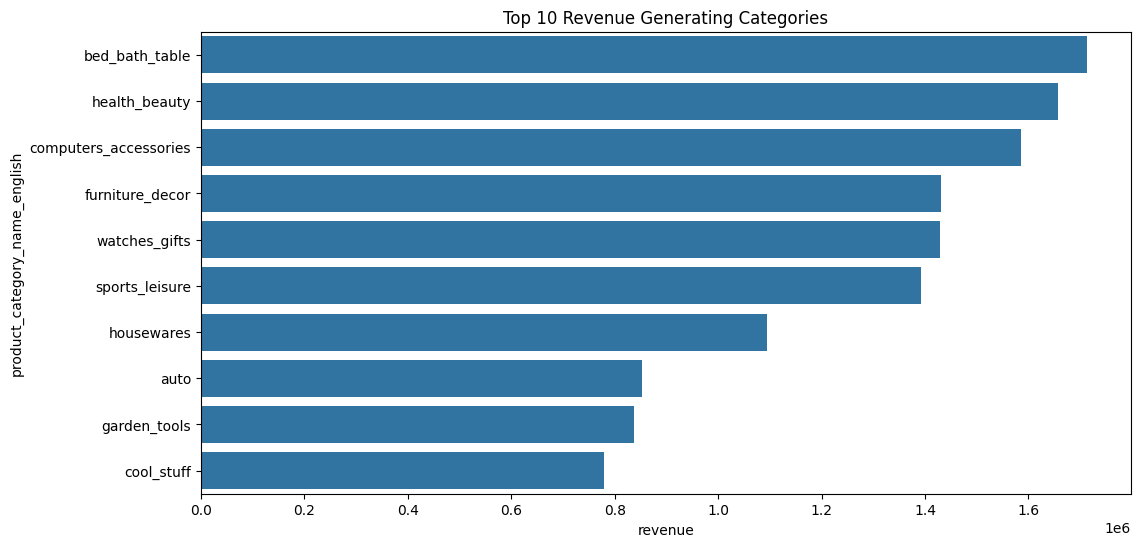

In [187]:
top_rev = category_revenue.head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top_rev, x='revenue', y='product_category_name_english')

plt.title("Top 10 Revenue Generating Categories")

plt.show()

## 7.2 Category Order Volume

In [188]:
category_orders = (master.groupby('product_category_name_english')
    .agg(orders=('order_id', 'nunique')).reset_index().sort_values('orders', ascending=False)
)

category_orders.head(10)

,product_category_name_english,orders
7,bed_bath_table,9417
43,health_beauty,8836
65,sports_leisure,7720
15,computers_accessories,6689
39,furniture_decor,6449
49,housewares,5884
70,watches_gifts,5624
68,telephony,4199
5,auto,3897
69,toys,3886


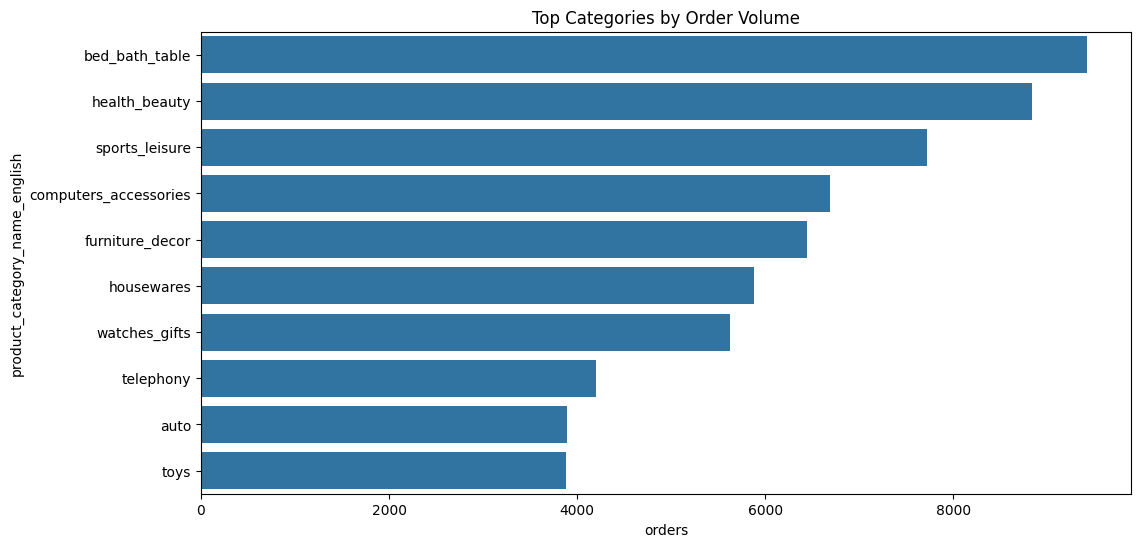

In [189]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_orders.head(10),
    x='orders',
    y='product_category_name_english'
)

plt.title("Top Categories by Order Volume")

plt.show()

## 7.3 Category AOV Analysis

In [190]:
category_aov = ( master.groupby('product_category_name_english')
    .agg(revenue=('total_payment_value','sum'),
        orders=('order_id','nunique')).reset_index())

category_aov['aov'] = (category_aov['revenue'] /category_aov['orders'])

category_aov.sort_values('aov',ascending=False).head(10)

,product_category_name_english,revenue,orders,aov
14,computers,279121.55,181,1542.108011
34,fixed_telephony,207010.26,217,953.964332
64,small_appliances_home_oven_and_coffee,51229.32,75,683.057600
0,agro_industry_and_commerce,118730.61,182,652.365989
45,home_appliances_2,124563.46,234,532.322479
57,office_furniture,646826.49,1273,508.111932
62,signaling_and_security,68488.05,140,489.200357
19,construction_tools_safety,65691.03,167,393.359461
56,musical_instruments,233074.12,628,371.137134
1,air_conditioning,91170.66,253,360.358340


##  7.4 Category Satisfaction

In [191]:
category_satisfaction = (master.groupby('product_category_name_english')
    .agg(orders=('order_id','nunique'),
        avg_review=('review_score','mean')
    ).reset_index()
)

category_satisfaction = (category_satisfaction[category_satisfaction['orders'] >= 100])

category_satisfaction.sort_values('avg_review',ascending=False).head(10)

,product_category_name_english,orders,avg_review
8,books_general_interest,512,4.446266
10,books_technical,260,4.363636
53,luggage_accessories,1034,4.315257
37,food_drink,227,4.310469
31,fashion_shoes,240,4.228682
36,food,450,4.218182
66,stationery,2311,4.196078
60,pet_shop,1710,4.184306
14,computers,181,4.175000
59,perfumery,3162,4.165932


## 7.5 Category Delivery Performance

In [192]:
category_delivery = ( master.groupby('product_category_name_english')
    .agg( orders=('order_id','nunique'),
        avg_delivery_days=('delivery_days','mean'),
        on_time_rate=('on_time_delivery','mean' )
    ).reset_index()
)

category_delivery = (category_delivery[category_delivery['orders'] >= 100])

category_delivery.sort_values('avg_delivery_days',ascending=False).head(10)

,product_category_name_english,orders,avg_delivery_days,on_time_rate
57,office_furniture,1273,20.841449,0.898285
12,christmas_supplies,128,15.740684,0.862745
31,fashion_shoes,240,15.441354,0.923664
45,home_appliances_2,234,13.906447,0.903361
40,furniture_living_room,422,13.795035,0.906561
42,garden_tools,3518,13.708882,0.903612
33,fashion_underwear_beach,121,13.706326,0.847328
16,consoles_games,1062,13.610097,0.883026
47,home_confort,397,13.532880,0.887097
14,computers,181,13.508088,0.916256


## 7.6 Category Opportunity Matrix

In [193]:
category_opportunity = (master.groupby('product_category_name_english')
    .agg(revenue=('total_payment_value','sum'),
        avg_review=( 'review_score', 'mean'),
        orders=('order_id','nunique')).reset_index())

category_opportunity = (category_opportunity[ category_opportunity['orders'] >= 100])

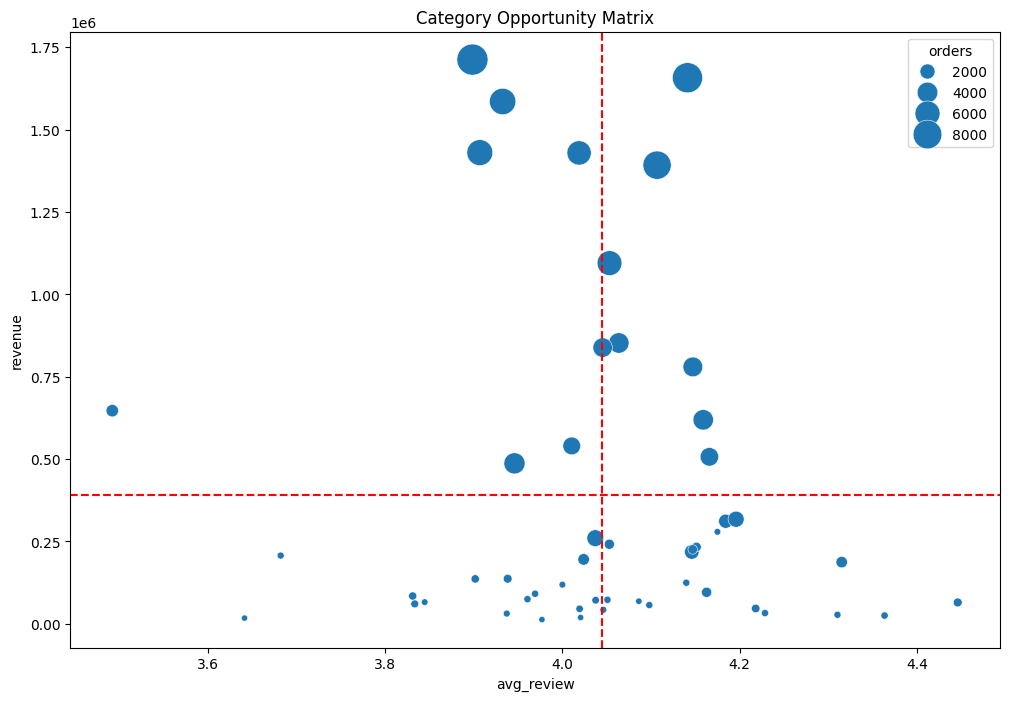

In [194]:
plt.figure(figsize=(12,8))

sns.scatterplot(data=category_opportunity,x='avg_review',y='revenue',size='orders',sizes=(20,500))

plt.axvline(category_opportunity['avg_review'].mean(),color='red',linestyle='--')

plt.axhline(category_opportunity['revenue'].mean(),color='red',linestyle='--')

plt.title('Category Opportunity Matrix')

plt.show()

### Category Opportunity Matrix

The category opportunity matrix reveals that not all categories contribute equally to marketplace performance.

Several categories combine high revenue with strong customer satisfaction and should be treated as strategic assets. These categories represent the healthiest segments of the marketplace and should be protected through inventory availability and service-quality monitoring.

More importantly, several high-revenue categories exhibit below-average customer satisfaction. These categories represent the largest improvement opportunity because even small customer-experience gains could generate significant business impact due to their scale.

The analysis suggests that management should prioritize operational improvements within high-revenue categories before expanding lower-revenue segments.

# 8. Geography Analysis

## 8.1 Revenue by State

In [195]:
state_revenue = (master.groupby('customer_state').agg(
        revenue=('total_payment_value','sum'),
        orders=('order_id','nunique')).reset_index().sort_values('revenue', ascending=False))

state_revenue.head(10)

,customer_state,revenue,orders
25,SP,7597209.66,41375
18,RJ,2769347.44,12762
10,MG,2326151.64,11544
22,RS,1147277.00,5432
17,PR,1064603.99,4998
4,BA,797410.36,3358
23,SC,786343.71,3612
8,GO,513879.00,2007
6,DF,432623.73,2125
7,ES,405805.34,2025


## 8.2 Orders by State

In [196]:
state_orders = (master.groupby('customer_state')
    .agg( orders=('order_id','nunique')).reset_index().sort_values('orders', ascending=False))

state_orders.head(10)

,customer_state,orders
25,SP,41375
18,RJ,12762
10,MG,11544
22,RS,5432
17,PR,4998
23,SC,3612
4,BA,3358
6,DF,2125
7,ES,2025
8,GO,2007


## 8.3 Delivery Performance by State

In [201]:
state_delivery = (master.groupby('customer_state')
    .agg( avg_delivery_days=('delivery_days','mean'),
          on_time_rate=('on_time_delivery','mean'),
          orders=('order_id','nunique')
    ).reset_index())

state_delivery = ( state_delivery[state_delivery['orders'] >= 100])

state_delivery.sort_values('avg_delivery_days',ascending=False).head(10)

,customer_state,avg_delivery_days,on_time_rate,orders
2,AM,26.390967,0.945455,147
1,AL,24.489142,0.729730,411
13,PA,23.754053,0.854630,970
9,MA,21.648667,0.773058,740
24,SE,21.467353,0.815584,345
5,CE,20.987465,0.817321,1327
14,PB,20.589148,0.863787,532
20,RO,19.739366,0.942446,247
16,PI,19.384710,0.815498,493
19,RN,19.325275,0.882798,482


## 8.4 Satisfaction by State

In [198]:
state_satisfaction = (master.groupby('customer_state')
    .agg(avg_review=('review_score','mean'),orders=('order_id','nunique')).reset_index())

state_satisfaction = (state_satisfaction[state_satisfaction['orders'] >= 100])

state_satisfaction.sort_values('avg_review',ascending=False).head(10)

,customer_state,avg_review,orders
25,SP,4.126825,41375
26,TO,4.108280,279
17,PR,4.107493,4998
2,AM,4.092025,147
10,MG,4.085879,11544
19,RN,4.080000,482
22,RS,4.052953,5432
11,MS,4.045288,709
20,RO,4.021661,247
23,SC,4.004588,3612


## 8.5 State Opportunity Matrix

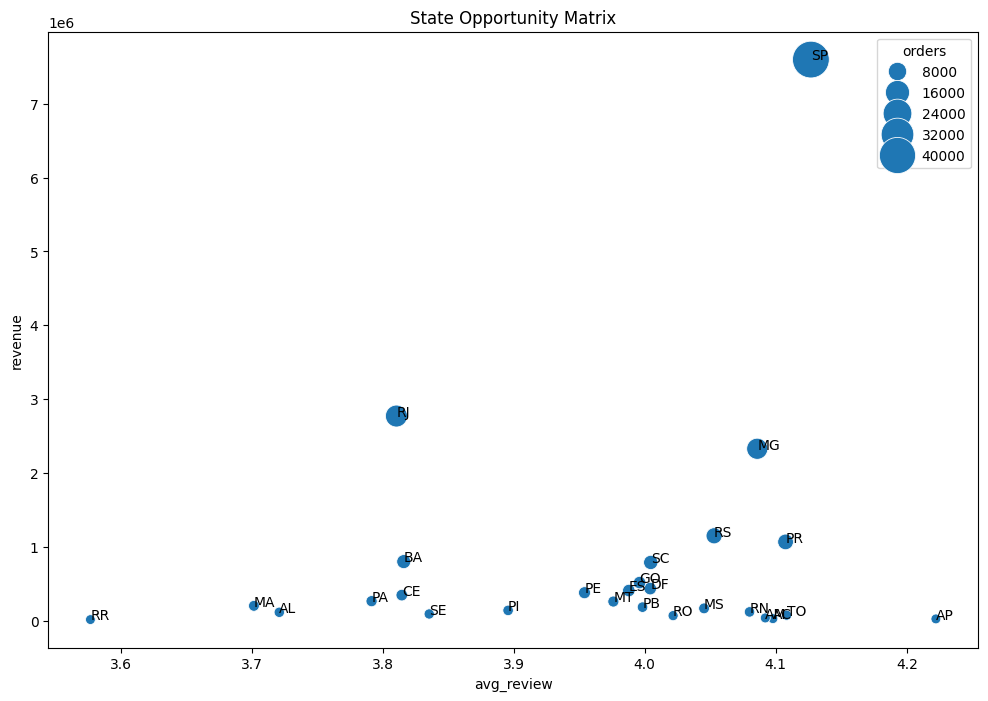

In [199]:
state_matrix = (master.groupby('customer_state')
    .agg(revenue=('total_payment_value','sum'),
        avg_review=('review_score','mean'),
        orders=('order_id','nunique')
    ).reset_index())

plt.figure(figsize=(12,8))

sns.scatterplot(data=state_matrix,
    x='avg_review',
    y='revenue',
    size='orders',
    sizes=(50,700)
)

for _, row in state_matrix.iterrows():
    plt.text(row['avg_review'],
        row['revenue'],
        row['customer_state']
    )

plt.title('State Opportunity Matrix')

plt.show()

### Geography Analysis Summary

Marketplace performance varies substantially across regions.

São Paulo (SP) is the dominant state in terms of revenue, customer volume, and overall marketplace activity. Importantly, SP also exhibits strong customer satisfaction and the shortest average delivery times among major states.

Several states experience substantially longer delivery durations, with average delivery times exceeding 20 days. These regions also tend to demonstrate weaker delivery reliability and lower customer satisfaction.

The results reinforce earlier findings that logistics performance is a major determinant of customer experience. Regional investments focused on transportation efficiency and delivery reliability are likely to generate measurable improvements in customer satisfaction.

From a business perspective, states such as Rio de Janeiro (RJ) and Minas Gerais (MG) represent attractive optimization opportunities because of their large revenue contributions and potential for customer-experience improvements.

# 9. Marketplace Health Assessment

## Objective

The purpose of this assessment is to consolidate findings from revenue, customer, delivery, satisfaction, category, and geography analyses into a single executive-level view of marketplace health.

The goal is to identify:

- Strengths of the marketplace
- Key operational risks
- Growth opportunities
- Strategic priorities for management

## Revenue Health

The marketplace generated more than 20 million in total revenue across approximately 98,700 orders and 95,400 customers.

Revenue demonstrates strong growth throughout the observation period, increasing from a small customer base in 2016 to monthly revenues exceeding 1.5 million during peak periods.

The strongest revenue months occur during Q4, particularly November and December, indicating the presence of seasonal demand patterns likely associated with promotional events and holiday shopping behavior.

### Assessment

✅ Revenue Growth: Healthy

✅ Revenue Scale: Healthy

⚠ Revenue Seasonality: Monitor

## Customer Health

The marketplace acquired more than 95,000 unique customers.

Customer acquisition increased consistently throughout the analysis period, demonstrating successful marketplace expansion.

However, repeat purchasing behavior remains relatively low, with only a small proportion of customers placing multiple orders.

This suggests that growth is currently driven more by customer acquisition than customer retention.

### Assessment

✅ Customer Acquisition: Strong

⚠ Customer Retention: Improvement Opportunity

⚠ Customer Loyalty: Monitor

## Delivery and Operations Health

The average delivery time is approximately 12.5 days, with a median delivery time of approximately 10 days.

The marketplace maintains an on-time delivery rate of approximately 90%.

Delivery lifecycle decomposition reveals that carrier transit time represents the largest component of total delivery duration, accounting for the majority of delivery delays.

Operational analysis indicates that logistics performance, rather than payment processing or order approval workflows, represents the primary operational bottleneck.

### Assessment

✅ On-Time Delivery Rate: Strong

⚠ Carrier Transit Efficiency: Improvement Opportunity

⚠ Regional Logistics Variability: Monitor

## Customer Satisfaction Health

Customer satisfaction remains generally strong, with an average review score exceeding 4 out of 5.

More than 75% of all reviews are either 4-star or 5-star ratings.

However, approximately 13% of reviews are 1-star ratings, indicating that a meaningful subset of customers experience severe dissatisfaction.

Statistical testing demonstrates that delivery reliability is the strongest driver of customer satisfaction.

Orders delivered on time achieve average review scores of 4.21 compared with only 2.37 for late deliveries.

The observed effect size (Cohen's d = 1.44) indicates an exceptionally large practical impact.

### Assessment

✅ Overall Satisfaction: Strong

⚠ Late Deliveries: Critical Risk

⚠ 1-Star Reviews: Root Cause Investigation Required

## Category Health

Revenue is concentrated within a relatively small number of product categories, particularly:

- Bed Bath Table
- Health Beauty
- Computers Accessories
- Furniture Decor
- Watches Gifts

Several categories combine high revenue and high satisfaction, representing healthy marketplace segments.

Other high-revenue categories demonstrate weaker customer satisfaction, creating attractive operational improvement opportunities.

### Assessment

✅ Category Portfolio Diversity: Strong

✅ High-Performing Categories: Present

⚠ High-Revenue / Low-Satisfaction Categories: Priority Focus Area

## Geographic Health

Marketplace activity is highly concentrated in São Paulo (SP), which contributes the largest share of revenue and orders.

SP also demonstrates strong customer satisfaction and superior delivery performance.

Several states exhibit significantly longer delivery times and weaker delivery reliability, suggesting regional logistics constraints.

These geographic disparities create opportunities for targeted operational investments.

### Assessment

✅ Core Market Performance (SP): Strong

⚠ Regional Delivery Variability: Improvement Opportunity

⚠ Logistics Coverage Inequality: Monitor

## Strategic Priorities

Based on the analysis, management should prioritize the following initiatives:

### Priority 1 — Reduce Late Deliveries

Late deliveries have the largest measurable impact on customer satisfaction.

Improving delivery reliability is likely to generate the highest customer experience ROI.

---

### Priority 2 — Improve Carrier Network Performance

Carrier transit time represents the largest operational bottleneck.

Investments in carrier optimization and transportation efficiency should be prioritized.

---

### Priority 3 — Increase Customer Retention

The marketplace demonstrates strong acquisition but limited repeat purchasing behavior.

Future growth initiatives should focus on retention, loyalty, and repeat order frequency.

---

### Priority 4 — Improve High-Revenue Categories

Operational improvements within high-revenue categories can generate disproportionately large business impact.

---

### Priority 5 — Optimize High-Revenue States

States such as RJ and MG represent attractive opportunities for customer experience improvement due to their revenue contribution and operational performance gaps.

# Executive Conclusion

The marketplace is fundamentally healthy and demonstrates strong revenue growth, expanding customer acquisition, high customer satisfaction, and reliable delivery performance.

However, the analysis identifies three key challenges:

1. Customer retention remains relatively weak.
2. Logistics performance varies significantly across regions.
3. Late deliveries create substantial customer dissatisfaction.

Among all analyzed variables, delivery reliability emerged as the strongest driver of customer satisfaction, with late deliveries reducing average review scores by nearly two rating points.

Future investments should therefore prioritize logistics reliability, carrier performance, and retention-focused growth strategies.

Overall, the marketplace is positioned for continued growth, but operational excellence in fulfillment and customer retention will be critical for sustaining long-term performance.